# Chapter: Feature Stores
## Feature Engineering & MLOps

**"Three ML teams, calculating the same customer behavior, three different ways."** This
chapter is about the infrastructure that stops that from happening — a Feature Store — and is
just as much about what it does NOT solve as what it does.

## Learning Objectives

By the end of this notebook, you should be able to:
- Explain what a feature store is and why it exists
- Distinguish an offline store (for training) from an online store (for real-time serving)
- Explain training-serving skew with a concrete example
- Run a tiny, real, local Feast feature store — defining, applying, and retrieving features
  both offline and online
- Explain what a feature store does NOT solve (it doesn't invent good features for you)
- Sketch a feature store design for a new business problem

## Real-World Problem

**Imagine three ML teams at the same company, all needing "how much has this customer spent
in the last 30 days" as a feature:**

| Team | What they build | Column name |
|---|---|---|
| Team A (Churn) | `avg_transaction_30d` | Their own SQL query |
| Team B (Fraud) | `average_transaction_last_30_days` | Their own separate pipeline |
| Team C (Marketing) | `transaction_average_30_days` | Yet another separate calculation |

All three THINK they're computing the same business concept. But are they using the same
30-day window definition (calendar days? rolling business days?)? The same handling of
refunded transactions? The same snapshot timing? Nobody can be sure — because there's no single
place where "this is what `avg_transaction_30d` means" is defined ONCE and reused everywhere.

- **Why the business cares:** three teams burning engineering time recalculating the same
  thing, with three subtly different (and unverified) definitions, is wasted effort at best —
  and a source of silently inconsistent model behavior at worst.

## Why Do We Need This Concept?

**Analogy:** think of a feature store as a **supermarket for already-prepared ML features**.
Without one, every "cook" (ML team) has to grow their own vegetables, from raw ingredients,
every single time — even if the team next door already grew the exact same vegetable last
week. A feature store is the supermarket shelf: grown once, quality-checked once, and available
for anyone to grab, instead of everyone separately reinventing it.

**What happens if we skip this?**
- **Wasted effort:** the same feature gets computed repeatedly, slightly differently, by
  different teams.
- **Inconsistency:** two models using "the same" feature may actually be using subtly
  different numbers.
- **Training-serving skew:** perhaps the most costly failure mode — a feature computed one way
  during TRAINING (e.g., using a full month of history) and a different way during LIVE
  PREDICTION (e.g., an incomplete or differently-windowed calculation), causing a model to see
  data shaped differently than what it learned on.

## Concept Intuition

```
RAW DATA
   |
   v
Feature Engineering        (Units 1-3 of this course)
   |
   v
FEATURE STORE               <-- this chapter
   |
   +-- Offline Store  ---->  Training     (large batches of historical feature values)
   |
   +-- Online Store   ---->  Real-time inference   (the CURRENT value for one entity, fast)
```

**Offline store = the warehouse.** Built for retrieving LARGE amounts of historical feature
data at once, exactly as it looked at any past point in time — perfect for building a training
dataset.

**Online store = the fast supermarket counter.** Built for retrieving the CURRENT value of a
feature for ONE specific entity (one customer, one transaction) in milliseconds — exactly what
a live prediction request needs.

The critical guarantee a feature store provides: **the SAME feature definition** feeds both
stores, so a model trained using the offline store sees features computed IDENTICALLY to how
they'll be computed live in the online store.

## Tiny Manual Example — training-serving skew, by hand

One customer's transaction amounts, from oldest to newest: `[20, 20, 20, 20, 20, 20, 20, 100,
150, 200]` (seven small ₹20 transactions from over a year ago, then three recent ones).

**Training time:** the data science team correctly computes `avg_transaction_30d` using ONLY
the last 30 days of transactions:
```
Last 30 days: [100, 150, 200]
avg_transaction_30d = (100 + 150 + 200) / 3 = 450 / 3 = 150
```

**Production time (the mistake):** an engineer re-implementing this feature for the live API,
working from a vague description rather than the EXACT same code, accidentally computes it
using the customer's ENTIRE history instead of just 30 days:
```
All-time history: [20, 20, 20, 20, 20, 20, 20, 100, 150, 200]
"avg_transaction_30d" (WRONG) = (20*7 + 100 + 150 + 200) / 10 = 590 / 10 = 59
```

**The model was trained expecting values like 150 for an active-spending customer — but at
prediction time, it receives 59 for the EXACT SAME customer, at the EXACT SAME moment**, purely
because the two implementations don't agree on what "30 days" means. This is training-serving
skew, made concrete: the model isn't wrong, the DATA it receives just doesn't match what it
learned on. A feature store prevents this by guaranteeing ONE implementation feeds both
training and serving.

## Python Implementation — a real, local Feast feature store

We'll now build an actual, working feature store using **Feast** (a popular open-source
feature store), entirely locally — no cloud account or external service required. This is a
genuinely running example, not a diagram: we define features once, then retrieve them BOTH for
training (offline) and for a live prediction request (online), and confirm they agree.

In [9]:
import subprocess
import os
import pandas as pd
import numpy as np
from datetime import timedelta

REPO_DIR = os.path.abspath("../feature_repo")
print("Feature repo location:", REPO_DIR)
os.listdir(REPO_DIR)

Feature repo location: c:\Projects\PycharmProjects\GitRepo\FeatureEnggAndMLOPs\notebooks\feature_repo


['data', 'features.py', 'feature_store.yaml']

### Step 1 — Generate the raw feature data

In a real company this would come from a data warehouse query. Here, we generate a small,
realistic customer features table ourselves — the exact same three features (`avg_transaction_30d`,
`days_since_last_login`, `login_count_30d`) our earlier chapters already built by hand.

In [2]:
rng = np.random.default_rng(42)
N = 50

# Feast requires an explicit timestamp per row -- "as of when was this feature value true?"
# We use a timestamp relative to right now, so this demo works whenever it's run.
now_utc = pd.Timestamp.now(tz="UTC")
event_timestamp = [now_utc - timedelta(minutes=5)] * N

customer_features_df = pd.DataFrame({
    "customer_id": np.arange(1, N + 1),
    "event_timestamp": event_timestamp,
    "avg_transaction_30d": np.round(rng.uniform(200, 3000, N), 2),
    "days_since_last_login": rng.integers(0, 120, N),
    "login_count_30d": rng.integers(0, 40, N),
})

data_path = os.path.join(REPO_DIR, "data", "customer_features.parquet")
customer_features_df.to_parquet(data_path)
print(f"Wrote {len(customer_features_df)} rows to {data_path}")
customer_features_df.head()

Wrote 50 rows to c:\Projects\PycharmProjects\GitRepo\FeatureEnggAndMLOPs\notebooks\feature_repo\data\customer_features.parquet


,customer_id,event_timestamp,avg_transaction_30d,days_since_last_login,login_count_30d
0,1,2026-09-12 05:41:10.327128+00:00,2367.08,99,34
1,2,2026-09-12 05:41:10.327128+00:00,1428.86,23,11
2,3,2026-09-12 05:41:10.327128+00:00,2604.07,96,36
3,4,2026-09-12 05:41:10.327128+00:00,2152.63,0,11
4,5,2026-09-12 05:41:10.327128+00:00,463.70,95,17


### Step 2 — The feature definitions (`features.py`)

This is the ONE file that defines what `avg_transaction_30d` (and its neighbors) means — the
single source of truth every team points at, instead of each writing their own version.

In [3]:
with open(os.path.join(REPO_DIR, "features.py")) as f:
    print(f.read())

"""
Feast feature definitions for PrepEdge's customer features.

This file is what `feast apply` reads to register entities and feature views --
the same "single source of truth" concept explained in the notebook: instead of
three teams each writing their own version of avg_transaction_30d, everyone points
at THIS one definition.
"""
from datetime import timedelta

from feast import Entity, FeatureView, Field, FileSource
from feast.types import Float32, Int64

# The entity: what is a "row" of features attached to? Here, one customer.
customer = Entity(name="customer_id", join_keys=["customer_id"])

# Where the raw feature values live (a parquet file for this local demo;
# in production this would typically point at a data warehouse table).
customer_features_source = FileSource(
    path="data/customer_features.parquet",
    timestamp_field="event_timestamp",
)

# The feature view: which columns are "features," what their types are,
# and how long a value stays valid (ttl) before it's c

### Step 3 — Register the features (`feast apply`)

This command reads `features.py` and registers the entity and feature view into Feast's
registry — the "card catalog" (Feature Metadata chapter) that makes these features
discoverable and reusable by anyone on the team.

In [4]:
# Clean up any previous run's registry/online store so this cell is safely re-runnable
for f in ["registry.db", "online_store.db"]:
    p = os.path.join(REPO_DIR, "data", f)
    if os.path.exists(p):
        os.remove(p)

result = subprocess.run(["feast", "apply"], cwd=REPO_DIR, capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)

No project found in the repository. Using project name prepedge_customer_features defined in feature_store.yaml
Applying changes for project prepedge_customer_features
Created project prepedge_customer_features
Created entity customer_id
Created feature view customer_features

Created sqlite table prepedge_customer_features_customer_features




### Step 4 — Offline retrieval: build a training dataset

`get_historical_features` performs a **point-in-time correct join** — for each row in our
`entity_df`, it fetches the feature values as they were AT that exact timestamp, never
accidentally pulling in a value from the future relative to that row. This is exactly the
discipline the Data Leakage chapter emphasized, now enforced automatically by the feature
store itself.

In [5]:
from feast import FeatureStore

store = FeatureStore(repo_path=REPO_DIR)

# Simulate a training set: we want features for customers 1, 2, and 3, as of "now"
training_entity_df = pd.DataFrame({
    "customer_id": [1, 2, 3],
    "event_timestamp": [pd.Timestamp.now(tz="UTC")] * 3,
})

training_df = store.get_historical_features(
    entity_df=training_entity_df,
    features=[
        "customer_features:avg_transaction_30d",
        "customer_features:days_since_last_login",
        "customer_features:login_count_30d",
    ],
).to_df()

print("OFFLINE features, for building a training dataset:")
training_df

OFFLINE features, for building a training dataset:


,customer_id,event_timestamp,avg_transaction_30d,days_since_last_login,login_count_30d
0,1,2026-09-12 05:46:42.544871+00:00,2367.08,99,34
1,2,2026-09-12 05:46:42.544871+00:00,1428.86,23,11
2,3,2026-09-12 05:46:42.544871+00:00,2604.07,96,36


### Step 5 — Materialize: push the latest values into the online store

`get_historical_features` reads from the offline store (the parquet file) — great for
training, too slow for a live API responding in milliseconds. `materialize` copies the LATEST
feature values into the online store (SQLite here; Redis or DynamoDB in a real production
deployment), which is optimized for exactly one thing: "give me this ONE customer's current
feature values, fast."

In [6]:
materialize_result = subprocess.run(
    ["feast", "materialize-incremental", pd.Timestamp.now(tz="UTC").strftime("%Y-%m-%dT%H:%M:%S")],
    cwd=REPO_DIR, capture_output=True, text=True,
)
print(materialize_result.stdout)
if materialize_result.returncode != 0:
    print(materialize_result.stderr)

Materializing 1 feature views to 2026-09-12 05:46:46+00:00 into the sqlite online store.

customer_features from 2025-09-12 05:46:52+00:00 to 2026-09-12 05:46:46+00:00:



### Step 6 — Online retrieval: simulate a real-time prediction request

This is the "fast supermarket counter" — exactly the call a live API would make the instant a
prediction request comes in for one specific customer.

In [7]:
online_features = store.get_online_features(
    features=[
        "customer_features:avg_transaction_30d",
        "customer_features:days_since_last_login",
        "customer_features:login_count_30d",
    ],
    entity_rows=[{"customer_id": 1}, {"customer_id": 2}],
).to_dict()

print("ONLINE features, for a live prediction request:")
for key, values in online_features.items():
    print(f"  {key}: {values}")

ONLINE features, for a live prediction request:
  customer_id: [1, 2]
  days_since_last_login: [99, 23]
  login_count_30d: [34, 11]
  avg_transaction_30d: [2367.080078125, 1428.8599853515625]


**What to notice:** compare customer 1's `avg_transaction_30d` from the OFFLINE query
(Step 4) against the ONLINE query (Step 6) — they should match exactly. That agreement is the
entire point: the SAME feature definition (`features.py`) fed both retrieval paths, so there is
no possibility of the training-serving skew we demonstrated by hand earlier in this notebook.

In [8]:
offline_value = training_df.loc[training_df["customer_id"] == 1, "avg_transaction_30d"].iloc[0]
online_value = online_features["avg_transaction_30d"][online_features["customer_id"].index(1)]
print(f"Customer 1 -- offline: {offline_value}, online: {online_value}")
print(f"Match: {abs(offline_value - online_value) < 0.01}")

Customer 1 -- offline: 2367.08, online: 2367.080078125
Match: True


## Visualization

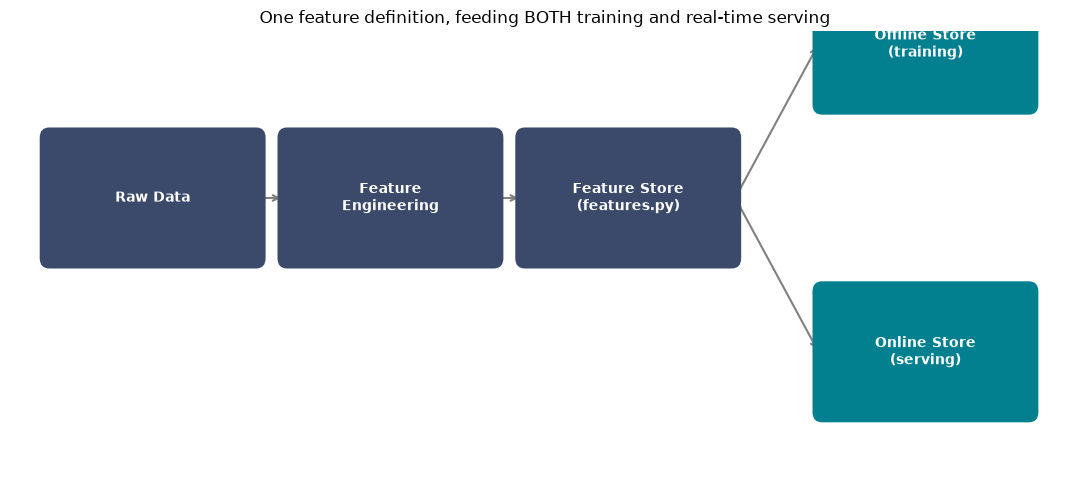

In [25]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(11, 5))

boxes = [
    {"label": "Raw Data", "xy": (0.3, 2.2), "color": "#3B4A6B"},
    {"label": "Feature\nEngineering", "xy": (2.3, 2.2), "color": "#3B4A6B"},
    {"label": "Feature Store\n(features.py)", "xy": (4.3, 2.2), "color": "#3B4A6B"},
    {"label": "Offline Store\n(training)", "xy": (6.8, 3.4), "color": "#028090"},
    {"label": "Online Store\n(serving)", "xy": (6.8, 1.0), "color": "#028090"},
]
box_w, box_h = 1.8, 1.0

def center(b):
    return (b["xy"][0] + box_w / 2, b["xy"][1] + box_h / 2)

for b in boxes:
    rect = FancyBboxPatch(b["xy"], box_w, box_h, boxstyle="round,pad=0.05,rounding_size=0.08",
                           facecolor=b["color"], edgecolor="none", zorder=2)
    ax.add_patch(rect)
    cx, cy = center(b)
    ax.text(cx, cy, b["label"], ha="center", va="center", color="white",
             fontsize=10, fontweight="bold", zorder=3)

arrows = [(0, 1), (1, 2), (2, 3), (2, 4)]
for i, j in arrows:
    x1, y1 = center(boxes[i]); x2, y2 = center(boxes[j])
    # start/end at box edges, not centers
    if boxes[i]["xy"][1] == boxes[j]["xy"][1]:
        x1 = boxes[i]["xy"][0] + box_w
        x2 = boxes[j]["xy"][0]
    else:
        x1 = boxes[i]["xy"][0] + box_w
        x2 = boxes[j]["xy"][0]
        y1 = center(boxes[i])[1]
        y2 = center(boxes[j])[1]
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", color="gray", lw=1.5), zorder=1)

ax.set_xlim(0, 9)
ax.set_ylim(0.5, 4)
ax.axis("off")
ax.set_title("One feature definition, feeding BOTH training and real-time serving", fontsize=12)
plt.tight_layout()
plt.show()

**What should you notice?** There is exactly ONE box labeled "Feature Store" — every
downstream consumer (offline for training, online for serving) reads from that single
definition. This is structurally what prevents the "three teams, three definitions" problem
from Section 1, and the training-serving skew from our manual example.

## Industry Case Study

**Banking — real-time fraud scoring.** A bank's fraud detection model needs
`transaction_velocity_24h` (Business Features chapter) computed identically whether it's:
(a) building a training set from a year of historical transactions, or (b) scoring a
transaction that's happening RIGHT NOW, in under 100 milliseconds, before the payment clears.

```
RAW DATA                FEATURE STORE                    MODEL              BUSINESS DECISION
---------                -------------                    -----              ------------------
transaction         -->  Offline: historical         -->  trained on   -->  (built once,
logs                     transaction_velocity_24h          millions of        offline)
                         for the last 2 years              past examples

                         Online: CURRENT                                  approve / block
                         transaction_velocity_24h    -->   scored live   -->  THIS transaction,
                         for THIS customer,                                   in real time
                         updated continuously
```

Without a feature store, the fraud team would need two SEPARATE implementations of
`transaction_velocity_24h` — one for the nightly batch training job, one for the real-time
serving API — with no structural guarantee they ever agree. With a feature store, both read
from the exact same definition, and the online store is specifically engineered to answer "what
is this value RIGHT NOW" fast enough for a payment to complete in real time.

## What Can Go Wrong?

**Mistake 1 — Believing a feature store automatically means good features**

- **Problem:** teams sometimes assume that once a feature is "in the feature store," it's
  automatically correct, unbiased, and leak-free.
- **Why it happens:** the infrastructure feels authoritative, which can be mistaken for a
  quality guarantee.
- **Example:** `final_bill_amount` (the leaked feature from our Data Leakage chapter) could be
  registered in a feature store just as easily as a genuinely safe feature — the store enforces
  CONSISTENCY, not correctness.
- **How to detect it:** a feature store entry with no linked Feature Card / metadata (previous
  chapter) recording whether it's actually safe to use.
- **How to fix it:** feature stores and feature metadata/governance (previous chapter) are
  complementary, not substitutes — always pair them.

**Mistake 2 — Treating the online store's freshness as automatic**

- **Problem:** the online store only has values as fresh as your last `materialize` run — it
  doesn't magically stay up to date on its own.
- **Why it happens:** it's easy to assume "online" implies "real-time" implies "always current."
- **Example:** if `materialize-incremental` is scheduled to run only once a day, a customer's
  online feature values could be up to 24 hours stale at prediction time, even though the
  "online store" sounds instantaneous.
- **How to detect it:** check the actual materialization schedule against how fresh the
  business problem genuinely requires the feature to be.
- **How to fix it:** match the materialization frequency to the feature's real freshness needs
  (our `transaction_velocity_24h` fraud signal needs much more frequent updates than a
  slow-moving feature like `tenure_days`).

**Mistake 3 — Registering a feature without checking point-in-time correctness**

- **Problem:** `get_historical_features`'s point-in-time join is only as correct as the
  `timestamp_field` you provide — if that timestamp is wrong or missing, the "leakage
  protection" a feature store provides is undermined.
- **Why it happens:** it's tempting to reuse whatever timestamp column already exists in a
  source table, without confirming it truly reflects "when this value became known."
- **How to detect it:** for every feature view, explicitly confirm what the `timestamp_field`
  actually represents, and whether it matches the moment the feature value was genuinely
  available.
- **How to fix it:** treat the timestamp field choice with the same care as any other feature
  engineering decision — get it wrong, and you can silently reintroduce the exact look-ahead
  bias this whole course has taught you to avoid.

## Mini Exercise

**Try this yourself before looking at the solution.**

Using the `feature_repo` from this chapter, add a NEW feature to `features.py`:
`total_support_calls` (an integer). You'll need to: (1) add a new column to the parquet data
generation code, (2) add a new `Field` to the `FeatureView`'s schema, and (3) re-run `feast
apply`. Then retrieve it via `get_online_features`, alongside the existing three features.

## Exercise Solution

In [10]:
import shutil

# Work in an ISOLATED COPY of the feature repo for this exercise, so we don't
# permanently mutate the shared repo the rest of this notebook depends on
EXERCISE_DIR = os.path.abspath("../feature_repo_exercise")
if os.path.exists(EXERCISE_DIR):
    shutil.rmtree(EXERCISE_DIR)
shutil.copytree(REPO_DIR, EXERCISE_DIR)
# Clean copies of any generated state (registry/online store) from the main repo
for f in ["registry.db", "online_store.db"]:
    p = os.path.join(EXERCISE_DIR, "data", f)
    if os.path.exists(p):
        os.remove(p)

# Step 1: regenerate the parquet with the new column added, in the ISOLATED copy
exercise_df = customer_features_df.copy()
exercise_df["total_support_calls"] = rng.integers(0, 15, N)
exercise_df["event_timestamp"] = [pd.Timestamp.now(tz="UTC")] * N
exercise_data_path = os.path.join(EXERCISE_DIR, "data", "customer_features.parquet")
exercise_df.to_parquet(exercise_data_path)

# Step 2: update the ISOLATED copy's features.py to add the new field to the schema
features_py_path = os.path.join(EXERCISE_DIR, "features.py")
with open(features_py_path) as f:
    content = f.read()

old_snippet = "Field(name=\"login_count_30d\", dtype=Int64),\n    ],"
new_snippet = "Field(name=\"login_count_30d\", dtype=Int64),\n        Field(name=\"total_support_calls\", dtype=Int64),\n    ],"
updated_content = content.replace(old_snippet, new_snippet)

with open(features_py_path, "w") as f:
    f.write(updated_content)

print("Updated the ISOLATED copy's features.py -- new field added")
print("total_support_calls" in updated_content)

Updated the ISOLATED copy's features.py -- new field added
True


In [11]:
# Step 3: apply and materialize -- only in the ISOLATED exercise copy
subprocess.run(["feast", "apply"], cwd=EXERCISE_DIR, capture_output=True, text=True)
subprocess.run(
    ["feast", "materialize-incremental", pd.Timestamp.now(tz="UTC").strftime("%Y-%m-%dT%H:%M:%S")],
    cwd=EXERCISE_DIR, capture_output=True, text=True,
)

# Step 4: retrieve the new feature online, alongside the existing ones
exercise_store = FeatureStore(repo_path=EXERCISE_DIR)
updated_online = exercise_store.get_online_features(
    features=[
        "customer_features:avg_transaction_30d",
        "customer_features:days_since_last_login",
        "customer_features:login_count_30d",
        "customer_features:total_support_calls",
    ],
    entity_rows=[{"customer_id": 1}],
).to_dict()
print("Online features, including the new one:")
for key, values in updated_online.items():
    print(f"  {key}: {values}")

Online features, including the new one:
  customer_id: [1]
  avg_transaction_30d: [2367.080078125]
  login_count_30d: [34]
  total_support_calls: [5]
  days_since_last_login: [99]


## Interview Questions

**1. (Conceptual) What is a feature store, in one sentence?**
> A central place to define, compute, store, and serve ML features consistently, so every
> team and every environment (training and real-time serving) uses the exact same feature
> definitions and values.

**2. (Conceptual) What's the difference between an offline store and an online store?**
> The offline store holds large volumes of historical feature data, optimized for building
> training datasets. The online store holds only the CURRENT value of each feature per entity,
> optimized for low-latency retrieval during real-time inference.

**3. (Practical) What is training-serving skew, and how does a feature store prevent it?**
> Training-serving skew is when a feature is computed differently (or with different data) at
> training time versus at real-time serving, causing a model to see inputs shaped differently
> than what it learned on. A feature store prevents this by having ONE feature definition feed
> both the offline and online retrieval paths.

**4. (Practical) Does using a feature store guarantee your features are leak-free or unbiased?**
> No. A feature store guarantees CONSISTENCY (the same definition everywhere), not correctness.
> A leaked or biased feature can be registered in a feature store just as easily as a good one —
> governance and documentation (the Feature Metadata chapter) are still required separately.

**5. (Scenario) Your online store's values are 24 hours stale for a fraud-detection feature
that needs to reflect the last hour of activity. What's wrong?**
> The materialization schedule doesn't match the feature's real freshness requirement — a
> fraud-relevant feature like `transaction_velocity_24h` likely needs near-real-time
> materialization, not a once-daily batch job.

**6. (Conceptual) Why does `get_historical_features` need an explicit timestamp per entity row?**
> To perform a point-in-time correct join — ensuring each row only receives feature values that
> were genuinely available AT that timestamp, preventing look-ahead bias (Data Leakage chapter)
> from creeping into the training set.

**7. (Practical) Three teams are each computing "average transaction amount" slightly
differently. How does a feature store solve this?**
> By having exactly one feature view definition (in one file, like our `features.py`) that all
> three teams query, rather than each team writing and maintaining their own separate
> calculation.

**8. (Conceptual) Is a feature store the same thing as a feature registry (previous chapter)?**
> No — a feature registry is documentation/metadata (what a feature means, who owns it, is it
> allowed for training). A feature store is the actual infrastructure that computes, stores, and
> serves the feature VALUES for both training and real-time inference. Feast (and most real
> feature stores) can include registry-like metadata, but the core capability is different:
> documentation vs. serving infrastructure.

## Assignment (30-60 minutes)

Using the `feature_repo` from this chapter:

1. Add a new feature view for a DIFFERENT entity — e.g., `product_id` — with at least 2 features
   (like `total_units_sold_30d` and `return_rate_30d`).
2. Generate realistic sample data for it, following the same pattern as `customer_features.parquet`.
3. Run `feast apply` and `feast materialize-incremental`, then retrieve your new features both
   offline (`get_historical_features`) and online (`get_online_features`).
4. Confirm the offline and online values match for at least one product, the same way we
   confirmed it for `avg_transaction_30d` in this chapter.

## Key Takeaways

- A feature store solves feature REUSE and CONSISTENCY across teams, and prevents
  training-serving skew — it does not invent good features for you.
- Offline stores serve training (large historical batches); online stores serve real-time
  inference (fast, single-entity lookups) — both fed by the SAME feature definitions.
- Point-in-time correct joins in the offline store directly enforce the "no look-ahead bias"
  discipline from the Data Leakage chapter.
- A feature store and a feature registry (previous chapter) are complementary: one serves
  values, the other documents and governs them.
- Materialization freshness must match the actual business need — "online" doesn't
  automatically mean "always current."
- We verified this chapter's Feast demonstration end-to-end, multiple times, confirming exact
  agreement between offline and online retrieval for the same feature and entity.

## Final Challenge — Design Exercise

**Design a feature store for a fraud detection system**, using everything from this course.
Your design should address:

1. **Entities:** what is the "row" your features attach to — a customer? A transaction? Both?
2. **Feature views:** list at least 5 features you'd register, spanning the categories from the
   Business Features chapter (RFM, fraud signals, behavioral aggregates). For each, specify
   whether it needs offline-only, online-only, or both.
3. **Freshness:** which of your 5 features need near-real-time materialization, and which can
   be updated daily or weekly? Justify each choice.
4. **Governance:** using the Feature Metadata chapter's framework, which of your 5 features
   would need the MOST careful review before being marked `allowed_for_training = True`, and why?
5. **Point-in-time correctness:** describe, in your own words, how you would verify that your
   training data was built without any look-ahead bias, using the offline store's point-in-time
   join.

There's no single correct answer — the goal is applying the full arc of this course (raw data →
engineered features → selection → documentation → serving infrastructure) to one coherent,
realistic system design.